In [1]:
!date

Fri Mar  6 10:26:24 AM EST 2026


In [2]:
pwd

'/projects/sccn/andromeda1/aglinska/deepcor-fmri-toolbox/tests'

In [3]:
# Import DeepCor configuration classes
from deepcor.config import (
    DeepCorConfig,
    ModelConfig,
    TrainingConfig,
    DataConfig,
)

# Import models
from deepcor.models import CVAE, cVAE, get_model, list_models

# Import training utilities
from deepcor.training import Trainer, save_model, save_brain_signals

# Import data utilities
from deepcor.data import (
    TrainDataset,
    get_roi_and_roni,
    get_obs_noi_list_coords,
    apply_dummy,
    censor_and_interpolate,
    apply_frame_censoring,
    plot_timeseries,
    array_to_brain,
    load_pickle,
    save_pickle,
)

# Import analysis utilities
from deepcor.analysis import (
    run_correlation_analysis_from_spec,
    run_contrast_analysis_from_spec,
    calc_and_save_compcor,
    average_signal_ensemble,
    get_design_matrix,
)

# Import visualization utilities
from deepcor.visualization import (
    init_track,
    update_track,
    show_dashboard,
    save_track,
)

# Import general utilities
from deepcor.utils import safe_mkdir, check_gpu_and_speedup

# Import high-level API
from deepcor.pipeline import DeepCorDenoiser

In [4]:
# ModelConfig: Configure the model architecture
model_config = ModelConfig(
    latent_dims=(8, 8),  # (shared dim, specific dim)
    beta=0.01,           # KLD loss weight
    gamma=0.0,           # TC loss weight
    delta=0.0,           # RONI zero constraint weight
    scale_MSE_GM=1e3,    # Gray matter reconstruction loss scale
    scale_MSE_CF=1e3,    # Non-gray matter reconstruction loss scale
    scale_MSE_FG=0.0,    # Foreground reconstruction loss scale
    do_disentangle=True  # Enable disentanglement
)
print(f"ModelConfig: latent_dims={model_config.latent_dims}, beta={model_config.beta}")

# TrainingConfig: Configure training parameters
training_config = TrainingConfig(
    n_epochs=5,
    batch_size=1024,
    learning_rate=0.001,
    optimizer='adamw',
    betas=(0.9, 0.999),
    eps=1e-08,
    max_grad_norm=5.0,
    n_repetitions=2  # Number of ensemble repetitions
)
print(f"TrainingConfig: n_epochs={training_config.n_epochs}, batch_size={training_config.batch_size}")

# DataConfig: Configure data preprocessing
data_config = DataConfig(
    n_dummy_scans=0,
    apply_censoring=False,
    censoring_threshold=0.5,
    confound_columns=['X', 'Y', 'Z', 'RotX', 'RotY', 'RotZ']
)

# Create a complete configuration
config = DeepCorConfig(
    model=model_config,
    training=training_config,
    data=data_config
)

ModelConfig: latent_dims=(8, 8), beta=0.01
TrainingConfig: n_epochs=5, batch_size=1024


In [5]:
# Check GPU availability and speedup

import torch
result = check_gpu_and_speedup()
print(f"GPU available: {result['gpu_available']}")
if result['gpu_available']:
    print(f"GPU name: {result['gpu_name']}")
    print(f"Average CPU time per op: {result['cpu_time']:.6f} s")
    print(f"Average GPU time per op: {result['gpu_time']:.6f} s")
    print(f"Speedup (CPU/GPU): {result['speedup']:.2f}x")
else:
    print(f"Average CPU time per op: {result['cpu_time']:.6f} s")

# Set device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}\n")

GPU available: True
GPU name: Tesla V100-SXM2-16GB
Average CPU time per op: 0.004588 s
Average GPU time per op: 0.000198 s
Speedup (CPU/GPU): 23.13x

Using device: cuda:0



### Define Paths

In [6]:
# Define Data Paths
# Cell Tagged parameters for papermill looping
import os
from pathlib import Path

bids_path = '../Data/fMRI-Data/studyforrest-fmriprep/'

subs = [sub for sub in os.listdir(os.path.join(bids_path)) if sub.startswith('sub-')]
subs.sort()

session = 'ses-localizer'
task = 'objectcategories'
space = 'MNI152NLin2009cAsym'

s = 0
r = 1
analysis_name = 'test-advanced'

In [7]:
sub_id = subs[s]
run = str(r)

print(sub_id)
print(run)
print(analysis_name)

sub-01
1
test-advanced


In [9]:
# Construct paths
base = os.path.join(bids_path,sub_id,session)

# EPI
epi_path = os.path.join(base,'func',f'{sub_id}_{session}_task-{task}_run-{run}_bold_space-{space}_preproc.nii.gz')

# Confounds
confounds_path = os.path.join(base,'func',f'{sub_id}_{session}_task-{task}_run-{run}_bold_confounds.tsv')

gm_mask_path = os.path.join(bids_path,'mask_roi.nii')
cf_mask_path = os.path.join(bids_path,'mask_roni.nii')

assert os.path.exists(epi_path), 'epi_path does not exist'
assert os.path.exists(confounds_path), 'confounds_path does not exist'
assert os.path.exists(gm_mask_path), 'gm_mask_path does not exist'
assert os.path.exists(cf_mask_path), 'cf_mask_path does not exist'

os.makedirs(os.path.join('../Data/DeepCor-Outputs',analysis_name), exist_ok=True)
output_dir = os.path.join('../Data/DeepCor-Outputs',analysis_name,f'DeepCor-Forrest-{sub_id}-{task}-{run}-cvae_v1')

print("EPI:", epi_path)
print("Confounds:", confounds_path)
print("output_dir:", output_dir)

EPI: ../Data/fMRI-Data/studyforrest-fmriprep/sub-01/ses-localizer/func/sub-01_ses-localizer_task-objectcategories_run-1_bold_space-MNI152NLin2009cAsym_preproc.nii.gz
Confounds: ../Data/fMRI-Data/studyforrest-fmriprep/sub-01/ses-localizer/func/sub-01_ses-localizer_task-objectcategories_run-1_bold_confounds.tsv
output_dir: ../Data/DeepCor-Outputs/test-advanced/DeepCor-Forrest-sub-01-objectcategories-1-cvae_v1


### Prepare data

In [10]:
import ants
import pandas as pd

In [11]:
epi = ants.image_read(epi_path)
df_conf = pd.read_csv(confounds_path, sep='\t') # Use tab separator
gm = ants.image_read(gm_mask_path)
cf = ants.image_read(cf_mask_path)

In [12]:
import deepcor

In [13]:
# Apply Dummy Scans
do_dummy = False
if do_dummy:
    ndummy = 8
    epi, df_conf = deepcor.data.apply_dummy(epi, df_conf, ndummy=ndummy)

In [14]:
do_frame_censoring = False
if do_frame_censoring:
    idx_censor = df_conf['FramewiseDisplacement'].values>0.01
    epi, df_conf = deepcor.data.apply_frame_censoring(epi,df_conf,idx_censor,also_nearby_voxels=True)

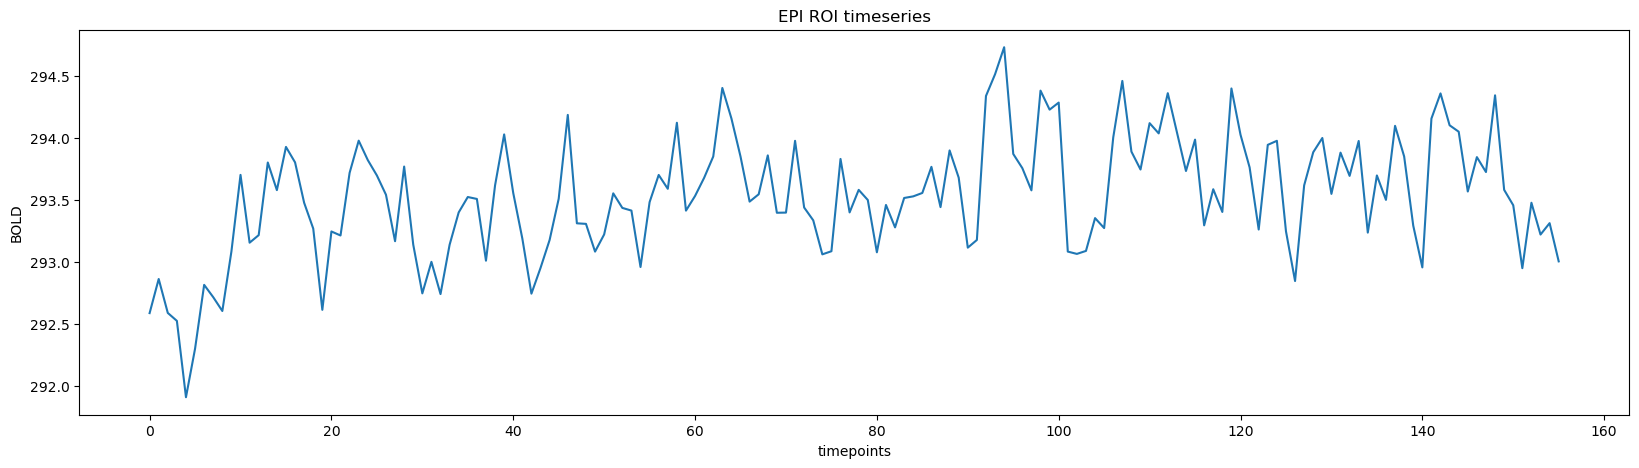

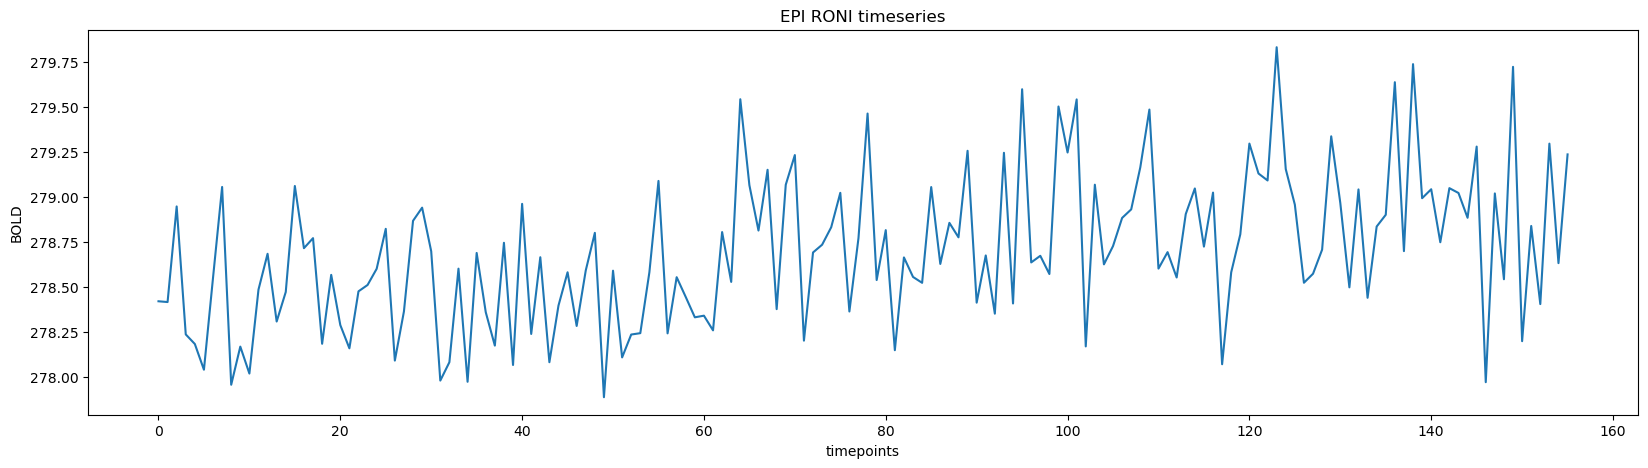

In [15]:
deepcor.data.plot_timeseries(epi,gm,cf)

In [16]:
obs_list, noi_list, gm, cf = deepcor.data.get_obs_noi_list(epi, gm, cf)
#obs_list, noi_list, gm, cf = deepcor.data.get_obs_noi_list(epi, gm, cf)

obs_list.shape: (41116, 156)
noi_list.shape: (9092, 156)
upsampling noi_list_coords
obs_list.shape: (41116, 156)
noi_list.shape: (41116, 156)


In [17]:
# Create DataLoader 
train_dataset = TrainDataset(obs_list, noi_list)
train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=config.training.batch_size, 
    shuffle=True, 
    drop_last=True
)

In [18]:
#Trainer

In [19]:
# in_channels: int,
# in_dim: int,
# latent_dim: int,
# hidden_dims: Union[List[int], NoneType] = None,

In [20]:
in_dim = obs_list.shape[1]
# Initialize Model
# We pass the Prepared confounds tensor here
model = deepcor.models.CVAE_V1(in_channels=1,in_dim=in_dim,latent_dim=8)
model = model.to(device)
print("Model initialized and moved to device")

Model initialized and moved to device


/home/aglinska/anaconda3/lib/python3.8/site-packages/torch/nn/init.py:453: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [21]:
# Initialize Trainer
trainer = Trainer(
    model,
    device=device,
    optimizer_type=config.training.optimizer,
    lr=config.training.learning_rate,
    betas=config.training.betas,
    eps=config.training.eps,
    max_grad_norm=config.training.max_grad_norm
)
print("Trainer initialized")

# Train the model
print(f"Starting training for {config.training.n_epochs} epochs...")
# We use a simple tracking dict for visualization
keys = [
    'l', 'kld_loss', 'recons_loss_roi', 'recons_loss_roni',
    'loss_recon_conf_s', 'loss_recon_conf_z', 'ncc_loss_tg',
    'ncc_loss_bg', 'ncc_loss_conf_s', 'ncc_loss_conf_z',
    'smoothness_loss', 'recons_loss_fg'
]
track = init_track(keys)

# Training loop
loss_history = []
for epoch in range(config.training.n_epochs):
    # Train one epoch
    avg_loss = trainer.train_epoch(train_loader)
    loss_history.append(avg_loss)
    
    # Update tracking (using a batch from loader for viz)
    with torch.no_grad():
        # Get a sample batch
        sample_batch = next(iter(train_loader))
        inputs_gm = sample_batch[0].to(device)
        inputs_cf = sample_batch[1].to(device)
        
        # Update track
        track = update_track(track, model, inputs_gm, inputs_cf)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{config.training.n_epochs}, Loss: {avg_loss:.4f}")

# Save outputs
print("Saving model and results...")
# Save checkpoint
trainer.save_checkpoint(
    os.path.join(output_dir, 'model_final.pt'), 
    config.training.n_epochs, 
    avg_loss
)

# Save track
save_track(os.path.join(output_dir, 'track.pickle'), track)

Trainer initialized
Starting training for 5 epochs...


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1024x2560 and 0x8)

In [ ]:
# Generate and save denoised brain files
print("Generating denoised brain signals...")
save_brain_signals(
    model, 
    train_dataset, 
    epi, 
    gm, 
    os.path.join(output_dir, 'denoised_deepcor.nii.gz'), 
    kind='FG'
)

# Also calculate compcor for comparison
print("Calculating CompCor...")
calc_and_save_compcor(
    epi, 
    gm, 
    cf, 
    os.path.join(output_dir, 'denoised_compcor.nii.gz'), 
    n_components=5
)

print("Done!")